In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

In [4]:
with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)

    mask[red] = 1
    mask[green] = 2
    mask[blue] = 3

    return mask

In [6]:
def preprocess_retina(image, fov):
    image = image * fov[:, :, None]

    green = image[:, :, 1]

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(green)

    enhanced = np.stack([enhanced, enhanced, enhanced], axis=-1)

    return enhanced

In [7]:
class AVDataset(Dataset):
    def __init__(self, file_list, base_path, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)
        fov_path = os.path.join(self.base_path, "masks", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(fov_path, 0)
        fov = (fov > 0).astype(np.uint8)

        image = preprocess_retina(image, fov)

        mask = convert_av_to_mask(av)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [8]:
train_dataset = AVDataset(train_files, BASE)
val_dataset = AVDataset(val_files, BASE)
test_dataset = AVDataset(test_files, BASE)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [10]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([4, 3, 768, 1152])
torch.Size([4, 768, 1152])
tensor([0, 1, 2, 3])


In [11]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

In [12]:
class_weights = torch.tensor([1.0, 8.0, 30.0, 8.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == targets).float().mean().item()
    return correct

In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)

        total_loss += loss.item()
        total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

In [16]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)

            total_loss += loss.item()
            total_acc += acc

    return total_loss / len(loader), total_acc / len(loader)

In [17]:
best_val_acc = 0
EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_av_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*50)

Epoch 1/20
Train Loss: 1.3878 | Train Acc: 0.3054
Val Loss: 1.4099 | Val Acc: 0.1614
--------------------------------------------------
Epoch 2/20
Train Loss: 1.2233 | Train Acc: 0.4880
Val Loss: 1.3938 | Val Acc: 0.2173
--------------------------------------------------
Epoch 3/20
Train Loss: 1.1178 | Train Acc: 0.5815
Val Loss: 1.2801 | Val Acc: 0.4761
--------------------------------------------------
Epoch 4/20
Train Loss: 1.0339 | Train Acc: 0.6631
Val Loss: 1.1835 | Val Acc: 0.6726
--------------------------------------------------
Epoch 5/20
Train Loss: 0.9625 | Train Acc: 0.7371
Val Loss: 1.0936 | Val Acc: 0.7789
--------------------------------------------------
Epoch 6/20
Train Loss: 0.8944 | Train Acc: 0.7954
Val Loss: 1.0034 | Val Acc: 0.9199
--------------------------------------------------
Epoch 7/20
Train Loss: 0.8270 | Train Acc: 0.8352
Val Loss: 0.9415 | Val Acc: 0.9348
--------------------------------------------------
Epoch 8/20
Train Loss: 0.7628 | Train Acc: 0.864

In [20]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]
    rgb[mask == 2] = [0, 255, 0]
    rgb[mask == 3] = [0, 0, 255]

    return rgb

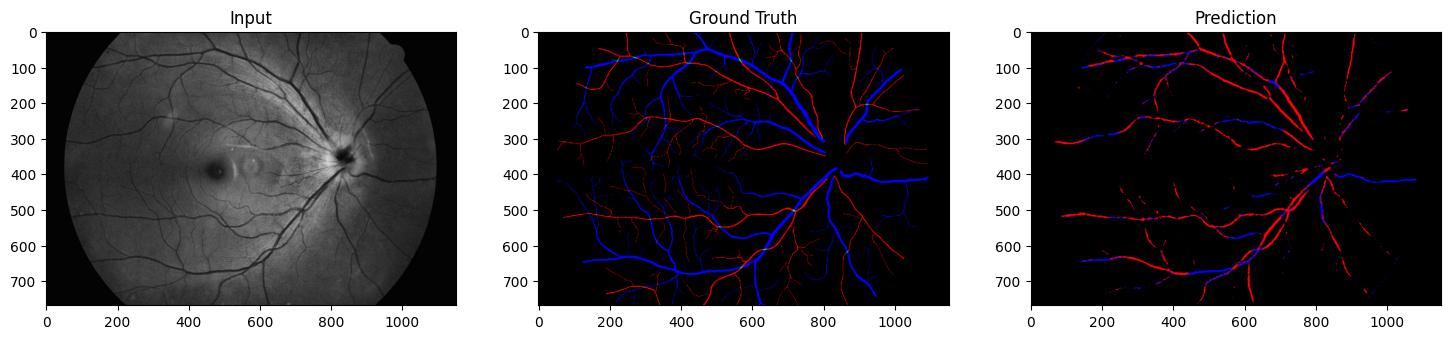

In [21]:
model.load_state_dict(torch.load("best_av_model.pth"))
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1,2,0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0].cpu().numpy()

gt_rgb = mask_to_rgb(gt)
pred_rgb = mask_to_rgb(pred)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt_rgb)
ax[1].set_title("Ground Truth")

ax[2].imshow(pred_rgb)
ax[2].set_title("Prediction")

plt.show()

In [22]:
import albumentations as A
print(A.__version__)

1.3.1
